In [1]:
import pandas as pd
from datetime import date, timedelta
from fiona.crs import from_epsg
import shapely
import math
import random
import geopandas as gpd
import numpy as np

enc = 'utf-8'
dec = 'greek8'
random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
def create_grid(river_shapes, data_shapes, col_municipal='NAME', col_geometry='geometry', dimension=2):
    """Creates the cell grid for the desired area
    
    Parameters
    --------
    river_shapes : dataframe,
        A GeoDataFrame containing the rivers of the area (to avoid creating cells on them)
                
    data_shapes : dataframe
        A GeoDataFrame containing the polygons (shapes) and the names of municipalities
        
    col_municipal : str, optional
        The column that contains the name for each municipality (default = 'NAME')
        
    col_geometry : string, optional
        The name of the column with the geometry of the river (default = 'geometry')
        
    dimension : int, optional
        The dimension of the square cell in km (eg. 2km x 2km, 1km x 1km) (default = 2)
        
    Returns
    ----------
    cell_df: dataframe
        A dataframe containing the generated cells for each municipality and the centers of each cell
    
    """
    river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
    # Convert cell height dimension to km
    cell_height = (dimension / 6378) * (180 / math.pi)
    
    grid_cells = []
    grid_cells2 = []
    municipal = []
    centers = []
    # Iterate over municipalities to create a grid for each one
    for i in range(data_shapes.shape[0]):
        area_cells = []
        center = []
        # Keep the geometry of municipality
        g_country = data_shapes[col_geometry][i]
        # Extract the bounds of municipality
        xmin, ymin, xmax, ymax = data_shapes[col_geometry][i:i+1].total_bounds
        # Convert cell width dimension to km (dependent to y)
        cell_width  = (dimension / 6378) * (180 / math.pi) / math.cos(ymin  * math.pi/180)
    
        # Iterate to municipality bounds to create the grid's cells
        for x0 in np.arange(xmin, xmax+cell_width, cell_width ):
            for y0 in np.arange(ymin, ymax+cell_height, cell_height):
                y1 = y0+cell_height
                x1 = x0+cell_width
                new_cell = shapely.geometry.box(x0, y0, x1, y1)
                # Check if new cell intersects the municipality
                if new_cell.covered_by(g_country):
                    # Check if new cell intersects previously generated cells
                    delete_cell_boundary = [True for cell in grid_cells2 if new_cell.intersects(cell)]
                    # Check if new cell intersects with rivers
                    delete_cell_river = [True for cell in river_shapes_list if new_cell.intersects(cell)]
                    # Save new cell if it doesn't intersects rivers or previous cells 
                    if not delete_cell_boundary and not delete_cell_river:
                        center.append(new_cell.centroid)
                        area_cells.append(new_cell)
                else:
                    # Continue to next cell generation
                    pass
        # Save the final cells for each municipality
        grid_cells.append(area_cells)
        # Save center of each cell
        centers.append(center)
        # Save municipality name for each generated cell
        municipal.append([data_shapes[col_municipal][i]]*len(area_cells))
        # Save the previous generated cells for intersection check
        grid_cells2 = []
        grid_cells2 = [item for sublist in grid_cells for item in sublist]

    # Flatten lists
    grid_cells_list = [item for sublist in grid_cells for item in sublist]
    centers_list = [item for sublist in centers for item in sublist]
    municipal_list = [item for sublist in municipal for item in sublist]
    
    # Create final GeoDataFrame with municipalities and their cells
    cell_df = gpd.GeoDataFrame(grid_cells_list, columns=[col_geometry], crs=from_epsg(4326))
    cell_df['centers'] = centers_list
    cell_df['NAME'] = municipal_list
    
    x = []
    y = []
    # Extract coordinates from centers
    for index,row in cell_df.iterrows():
        x.append(round(row['centers'].x,5))
        y.append(round(row['centers'].y,5))  
        
    cell_df['x'] = x
    cell_df['y'] = y
    
    return cell_df

def read_river_shapes(col_id, path_rivers, col_geometry='geometry', filter=False, num_region=0, path_region='', *args):
    """Reads rivers shapefile and returns a geopandas dataframe
    
    Parameters
    --------
    col_id : string,
        The name of the column with the id of the river
                
    path_rivers : string
        Path to shapefile of rivers
        
    col_geometry : string, optional
        The name of the column with the geometry of the river (default = 'geometry')
        
    filter : boolean, optional
        If false all rivers will be return (default = False)
        
    num_region : int,optional
        The number of the row of the desired region in GeoDataFrame (default = 0)
        
    path_region : string, optional
        Path to shapefile of region that its' rivers will be kept
        
    data_shapes : dataframe, optional (pass with *args)
        A GeoDataFrame containing the polygons (shapes) and the names of municipalities

    Returns
    ----------
    data: dataframe
        A dataframe containing the desired river shapes
    
    """
    try:
        # reading as shp file
        river_shapes = gpd.read_file(path_rivers, encoding="utf_8")
    except: 
        raise NotImplementedError("Sorry, give me a .shp file.")
    if filter:
        indexes = []
        if path_region:
            try:
                # reading as shp file
                region = gpd.read_file(path_region, encoding="utf_8")
            except: 
                raise NotImplementedError("Sorry, give me a .shp file.")
            for index, row in river_shapes.iterrows():
                if row[col_geometry].intersects(region[col_geometry][num_region]):
                    indexes.append(index)
        else:
            data_shapes=args[0]
            for index, row in river_shapes.iterrows():
                for index2, row2 in data_shapes.iterrows():
                    if row[col_geometry].intersects(row2[col_geometry]):
                        indexes.append(index)
                
        river_shapes = river_shapes.loc[indexes].reset_index(drop=True)
    river_shapes = river_shapes[[col_id, col_geometry]]
    return river_shapes

def process_greek(frame, column):
    frame[column] = frame[column].apply(lambda x : x.strip())
    frame[column] = frame[column].apply(lambda x : x.lower())
    frame[column] = frame[column].apply(lambda x : x.replace('ά','α'))
    frame[column] = frame[column].apply(lambda x : x.replace('έ','ε'))
    frame[column] = frame[column].apply(lambda x : x.replace('ή','η'))
    frame[column] = frame[column].apply(lambda x : x.replace('ί','ι'))
    frame[column] = frame[column].apply(lambda x : x.replace('ύ','υ'))
    frame[column] = frame[column].apply(lambda x : x.replace('ό','ο'))
    frame[column] = frame[column].apply(lambda x : x.replace('ώ','ω'))

In [3]:
## Reading shapefiles from Greece
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"


greece_gdf = gpd.read_file(f"{folder_path}/elladitsa.shp",  encoding=enc)
greece_regions_gdf = gpd.read_file(f"{folder_path}/perifereies2.shp",  encoding=enc)
rivers_gdf = gpd.read_file(f"{folder_path}/potamoi2.shp", encoding=enc)

In [4]:
greece_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [5]:
greece_regions_gdf.head()

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."
2,Π. ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"POLYGON ((20.77648 40.35294, 20.77652 40.35548..."
3,Π. ΗΠΕΙΡΟΥ,"MULTIPOLYGON (((20.00882 39.69130, 20.00884 39..."
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [6]:
thessaly_region_gdf = greece_regions_gdf.loc[greece_regions_gdf['PER'] == 'Π. ΘΕΣΣΑΛΙΑΣ']
thessaly_region_gdf.head()

,PER,geometry
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [7]:
indexes = []

region = thessaly_region_gdf

for index, row in greece_gdf.iterrows():
    for index2, row2 in region.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

thessaly_gdf = greece_gdf.loc[indexes].reset_index(drop=True)

In [8]:
thessaly_gdf.head()

,NAME,KWD_YPES,geometry
0,Αγιάς,9097,"MULTIPOLYGON (((22.89063 39.67169, 22.89056 39..."
1,Αγράφων,9156,"POLYGON ((21.64628 39.24473, 21.64720 39.24471..."
2,Αλοννήσου,9109,"MULTIPOLYGON (((24.14310 39.34155, 24.14307 39..."
3,Αλμυρού,9104,"MULTIPOLYGON (((23.06753 39.00526, 23.06740 39..."
4,Αμφιλοχίας,9125,"MULTIPOLYGON (((21.15577 38.98239, 21.15567 38..."


<AxesSubplot:>

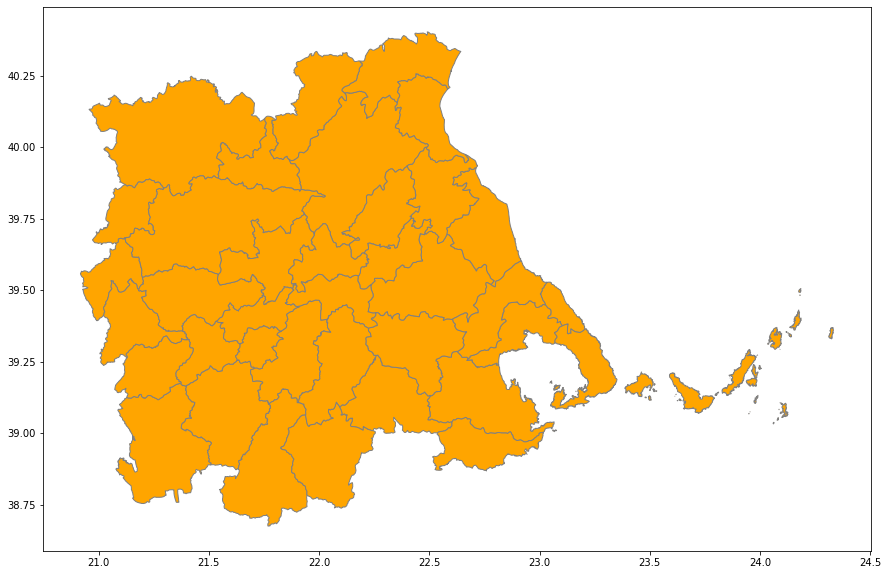

In [9]:
thessaly_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [10]:
wrong_list = ['Δίου - Ολύμπου' ,'Κατερίνης', 'Σερβίων - Βελβεντού', 'Δεσκάτης', 'Γρεβενών', 'Μετσόβου', 'Βορείων Τζουμέρκων', 'Κεντρικών Τζουμέρκων',
 'Γεωργίου Καραϊσκάκη', 'Αμφιλοχίας', 'Αγράφων', 'Καρπενησίου', 'Μακρακώμης', 'Δομοκού', 'Στυλίδας']

thessaly_gdf = thessaly_gdf[~thessaly_gdf['NAME'].isin(wrong_list)].copy()

In [11]:
thessaly_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Αγιάς,9097,"MULTIPOLYGON (((22.89063 39.67169, 22.89056 39..."
2,Αλοννήσου,9109,"MULTIPOLYGON (((24.14310 39.34155, 24.14307 39..."
3,Αλμυρού,9104,"MULTIPOLYGON (((23.06753 39.00526, 23.06740 39..."
5,Αργιθέας,9091,"POLYGON ((21.43616 39.41522, 21.43830 39.41454..."
6,Βόλου,9105,"POLYGON ((22.97208 39.45655, 22.97346 39.45643..."


In [12]:
thessaly_gdf.drop(columns=['KWD_YPES'], inplace = True)
thessaly_gdf.rename(columns={"NAME": "lau1"}, inplace = True)
process_greek(thessaly_gdf, 'lau1')

In [13]:
thessaly_gdf.head(5)

,lau1,geometry
0,αγιας,"MULTIPOLYGON (((22.89063 39.67169, 22.89056 39..."
2,αλοννησου,"MULTIPOLYGON (((24.14310 39.34155, 24.14307 39..."
3,αλμυρου,"MULTIPOLYGON (((23.06753 39.00526, 23.06740 39..."
5,αργιθεας,"POLYGON ((21.43616 39.41522, 21.43830 39.41454..."
6,βολου,"POLYGON ((22.97208 39.45655, 22.97346 39.45643..."


<AxesSubplot:>

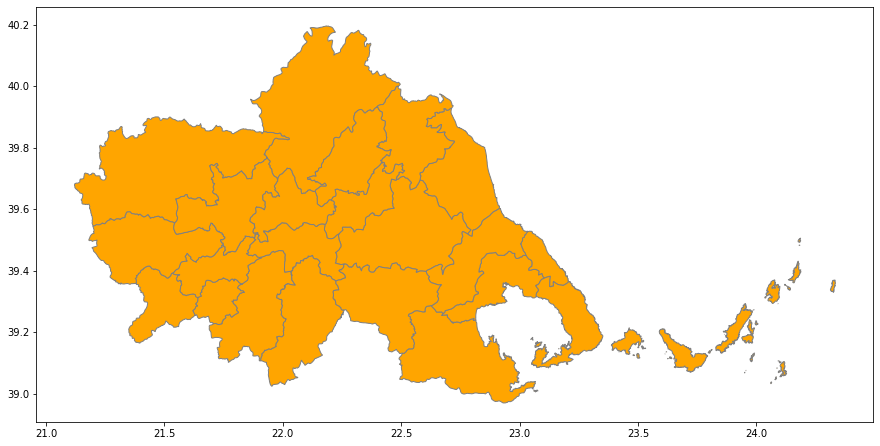

In [14]:
thessaly_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [15]:
indexes = []

region = thessaly_region_gdf

for index, row in rivers_gdf.iterrows():
    for index2, row2 in region.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

thessaly_rivers_gdf = rivers_gdf.loc[indexes].reset_index(drop=True)

In [16]:
thessaly_rivers_gdf.head()

,objectid,eu_cd,name,altname1,altname2,altname3,region_cd,system,ins_when,ins_by,...,acid_neut,substratum,chloride,a_temp_rge,av_a_temp,ppt,dist_sourc,cont,shape_Leng,geometry
0,3,GR0004000400260520N,ÔÁÕÑÙÐÏÓ Ð.,TAVROPOS R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,42710.979405,"LINESTRING (21.76727 39.18674, 21.76728 39.186..."
1,5,GR0008000400220360N,ÅÍÉÐÅÕÓ Ð.,ENIPEYS R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,13274.085824,"LINESTRING (22.11585 39.49631, 22.11806 39.495..."
2,31,GR0008000400220550N,ÊÁÑÁÌÐÁËÇÓ Ð.,KARABALIS R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,4406.675683,"LINESTRING (21.93452 39.34592, 21.93566 39.346..."
3,34,GR0008000400220580N,ÐÇÍÅÉÏÓ Ð.,PINIOS R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,4406.675683,"LINESTRING (22.02974 39.55998, 22.03116 39.561..."
4,35,GR0008000400220360N,ÅÍÉÐÅÕÓ Ð.,ENIPEYS R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,38733.609281,"LINESTRING (22.52914 39.30856, 22.52884 39.308..."


<AxesSubplot:>

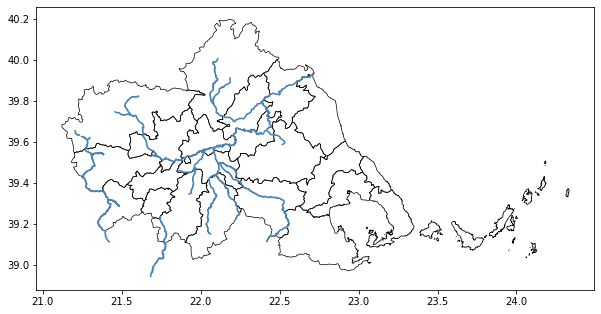

In [17]:
ax = thessaly_rivers_gdf.plot(markersize=.1, figsize=(10, 10), cmap='jet', color='steelblue')
thessaly_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.7)

In [18]:
thessaly_lau1 = thessaly_gdf['lau1'].unique().tolist()

with open('data/GR_SHP_Thessaly_lau1_processed.txt', 'w', encoding=enc) as f:
    for item in thessaly_lau1:
        f.write("%s\n" % item)

print(f"Number of LAU1 Units in Thessaly (from shapefile): {len(thessaly_lau1)}")

Number of LAU1 Units in Thessaly (from shapefile): 25


In [19]:
thessaly_gdf.reset_index(inplace=True, drop = True)
thessaly_rivers_gdf.reset_index(inplace=True, drop=True)

In [20]:
df_grid = create_grid(thessaly_rivers_gdf, thessaly_gdf, col_municipal='lau1', dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

C:\Users\dimit\AppData\Local\Temp/ipykernel_26656/2153756921.py:27: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\dtypes\cast.py:118: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert t

In [21]:
df_grid.rename(columns={"NAME": "lau1"}, inplace = True)

<AxesSubplot:>

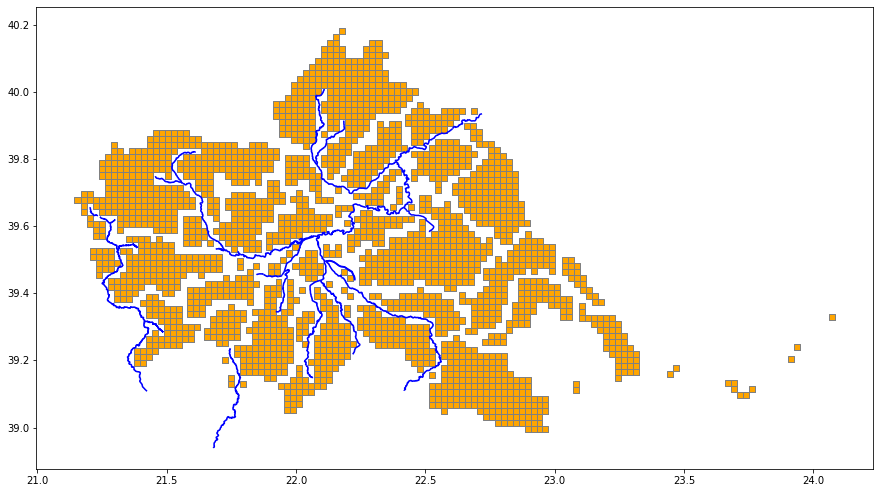

In [22]:
ax = thessaly_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='blue')
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [23]:
grid_lau1 = df_grid['lau1'].unique().tolist()
print(f"Number of LAU1 Units in Grid: {len(grid_lau1)}")

Number of LAU1 Units in Grid: 25


In [24]:
if (len(thessaly_lau1) != len(grid_lau1)):
    delta = [item for item in thessaly_lau1 if item not in grid_lau1]
    print(delta)

    lost_lau1 = thessaly_gdf[thessaly_gdf['lau1'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_thessaly_grid = pd.DataFrame()
    add_to_thessaly_grid['lau1'] = lost_lau1['lau1']
    add_to_thessaly_grid['geometry'] = lost_lau1['geometry']
    add_to_thessaly_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_thessaly_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [25]:
thessaly_grid = df_grid.drop(columns=['centers'])

In [26]:
thessaly_grid

,geometry,lau1,x,y
0,"POLYGON ((22.62551 39.69172, 22.62551 39.70969...",αγιας,22.61387,39.70070
1,"POLYGON ((22.62551 39.70969, 22.62551 39.72765...",αγιας,22.61387,39.71867
2,"POLYGON ((22.64880 39.65579, 22.64880 39.67375...",αγιας,22.63715,39.66477
3,"POLYGON ((22.64880 39.67375, 22.64880 39.69172...",αγιας,22.63715,39.68274
4,"POLYGON ((22.64880 39.69172, 22.64880 39.70969...",αγιας,22.63715,39.70070
...,...,...,...,...
2270,"POLYGON ((22.60653 39.36391, 22.60653 39.38188...",φαρσαλων,22.59495,39.37290
2271,"POLYGON ((22.62969 39.29205, 22.62969 39.31001...",φαρσαλων,22.61811,39.30103
2272,"POLYGON ((22.62969 39.31001, 22.62969 39.32798...",φαρσαλων,22.61811,39.31900
2273,"POLYGON ((22.62969 39.32798, 22.62969 39.34595...",φαρσαλων,22.61811,39.33696


In [27]:
if (len(thessaly_lau1) != len(grid_lau1)):
    thessaly_grid = pd.concat([thessaly_grid, add_to_thessaly_grid], axis=0)

thessaly_grid.reset_index(inplace=True, drop=True)

In [28]:
thessaly_grid['nuts3'] = 'θεσσαλιας'

In [29]:
thessaly_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [30]:
thessaly_grid

,shape,lau1,x,y,nuts3
0,"POLYGON ((22.62551 39.69172, 22.62551 39.70969...",αγιας,22.61387,39.70070,θεσσαλιας
1,"POLYGON ((22.62551 39.70969, 22.62551 39.72765...",αγιας,22.61387,39.71867,θεσσαλιας
2,"POLYGON ((22.64880 39.65579, 22.64880 39.67375...",αγιας,22.63715,39.66477,θεσσαλιας
3,"POLYGON ((22.64880 39.67375, 22.64880 39.69172...",αγιας,22.63715,39.68274,θεσσαλιας
4,"POLYGON ((22.64880 39.69172, 22.64880 39.70969...",αγιας,22.63715,39.70070,θεσσαλιας
...,...,...,...,...,...
2270,"POLYGON ((22.60653 39.36391, 22.60653 39.38188...",φαρσαλων,22.59495,39.37290,θεσσαλιας
2271,"POLYGON ((22.62969 39.29205, 22.62969 39.31001...",φαρσαλων,22.61811,39.30103,θεσσαλιας
2272,"POLYGON ((22.62969 39.31001, 22.62969 39.32798...",φαρσαλων,22.61811,39.31900,θεσσαλιας
2273,"POLYGON ((22.62969 39.32798, 22.62969 39.34595...",φαρσαλων,22.61811,39.33696,θεσσαλιας


In [31]:
thessaly_grid_points = gpd.GeoDataFrame(thessaly_grid, geometry=gpd.points_from_xy(thessaly_grid.x, thessaly_grid.y))

In [32]:
thessaly_grid_points

,shape,lau1,x,y,nuts3,geometry
0,"POLYGON ((22.62551 39.69172, 22.62551 39.70969...",αγιας,22.61387,39.70070,θεσσαλιας,POINT (22.61387 39.70070)
1,"POLYGON ((22.62551 39.70969, 22.62551 39.72765...",αγιας,22.61387,39.71867,θεσσαλιας,POINT (22.61387 39.71867)
2,"POLYGON ((22.64880 39.65579, 22.64880 39.67375...",αγιας,22.63715,39.66477,θεσσαλιας,POINT (22.63715 39.66477)
3,"POLYGON ((22.64880 39.67375, 22.64880 39.69172...",αγιας,22.63715,39.68274,θεσσαλιας,POINT (22.63715 39.68274)
4,"POLYGON ((22.64880 39.69172, 22.64880 39.70969...",αγιας,22.63715,39.70070,θεσσαλιας,POINT (22.63715 39.70070)
...,...,...,...,...,...,...
2270,"POLYGON ((22.60653 39.36391, 22.60653 39.38188...",φαρσαλων,22.59495,39.37290,θεσσαλιας,POINT (22.59495 39.37290)
2271,"POLYGON ((22.62969 39.29205, 22.62969 39.31001...",φαρσαλων,22.61811,39.30103,θεσσαλιας,POINT (22.61811 39.30103)
2272,"POLYGON ((22.62969 39.31001, 22.62969 39.32798...",φαρσαλων,22.61811,39.31900,θεσσαλιας,POINT (22.61811 39.31900)
2273,"POLYGON ((22.62969 39.32798, 22.62969 39.34595...",φαρσαλων,22.61811,39.33696,θεσσαλιας,POINT (22.61811 39.33696)


<AxesSubplot:>

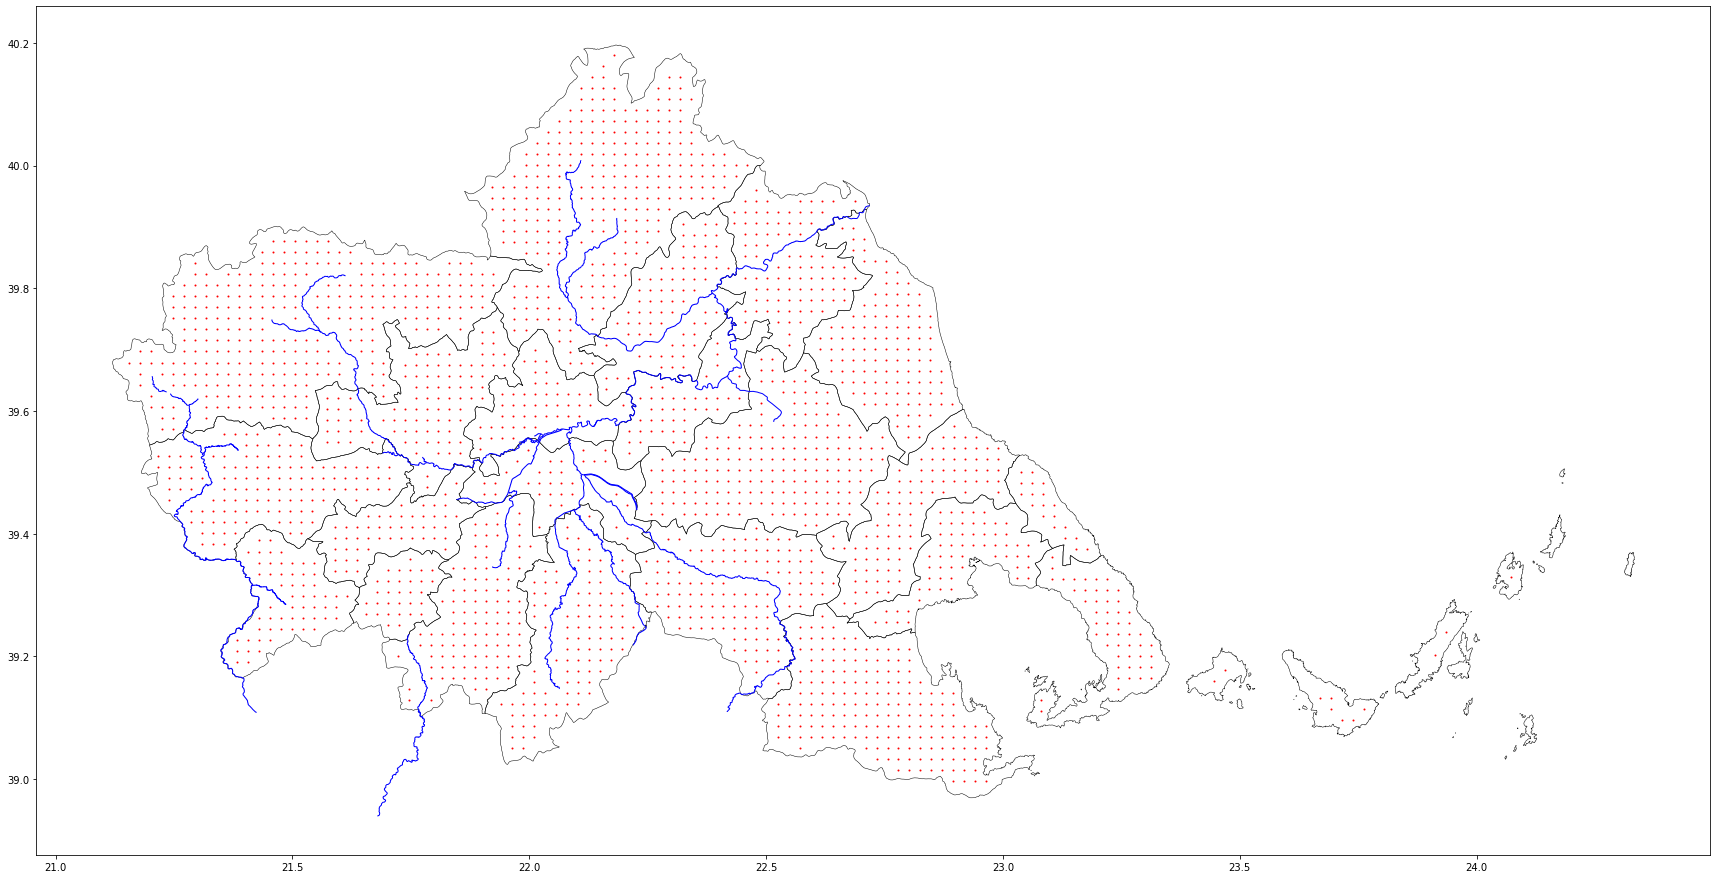

In [33]:
ax = thessaly_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
thessaly_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
thessaly_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [34]:
value_counts = thessaly_grid['lau1'].value_counts().sort_values()

In [35]:
arr = value_counts.values

In [36]:
arr_norm = np.ceil((15*(arr - np.min(arr) + 1 )/np.ptp(arr))).astype(int)

In [37]:
value_counts_target = pd.Series(data=arr_norm, index=value_counts.index)

In [38]:
value_counts_target

σκιαθου                 1
αλοννησου               1
σκοπελου                1
ζαγορας - μουρεσιου     1
λιμνης πλαστηρα         2
παλαμα                  2
λαρισαιων               2
φαρκαδονας              3
μουζακιου               3
νοτιου πηλιου           3
αργιθεας                3
βολου                   3
τυρναβου                4
τεμπων                  5
τρικκαιων               5
ρηγα φερραιου           5
σοφαδων                 6
καρδιτσας               6
φαρσαλων                7
αγιας                   7
πυλης                   7
αλμυρου                 9
κιλελερ                10
ελασσονας              14
καλαμπακας             16
dtype: int32

In [39]:
idx = []
points = [] 

for index, value in value_counts_target.iteritems():
    if value == value_counts[index]:
        pass
    else: 
        idx.append(index)
        points.append(value_counts[index] - value)
        print(f'Index: {index} || Value: {value_counts[index]} || Target Value: {value}')

Index: σκιαθου || Value: 2 || Target Value: 1
Index: αλοννησου || Value: 3 || Target Value: 1
Index: σκοπελου || Value: 6 || Target Value: 1
Index: ζαγορας - μουρεσιου || Value: 19 || Target Value: 1
Index: λιμνης πλαστηρα || Value: 31 || Target Value: 2
Index: παλαμα || Value: 33 || Target Value: 2
Index: λαρισαιων || Value: 40 || Target Value: 2
Index: φαρκαδονας || Value: 47 || Target Value: 3
Index: μουζακιου || Value: 48 || Target Value: 3
Index: νοτιου πηλιου || Value: 50 || Target Value: 3
Index: αργιθεας || Value: 57 || Target Value: 3
Index: βολου || Value: 59 || Target Value: 3
Index: τυρναβου || Value: 75 || Target Value: 4
Index: τεμπων || Value: 91 || Target Value: 5
Index: τρικκαιων || Value: 94 || Target Value: 5
Index: ρηγα φερραιου || Value: 95 || Target Value: 5
Index: σοφαδων || Value: 103 || Target Value: 6
Index: καρδιτσας || Value: 107 || Target Value: 6
Index: φαρσαλων || Value: 122 || Target Value: 7
Index: αγιας || Value: 123 || Target Value: 7
Index: πυλης || 

In [40]:
to_remove = pd.Series(data=points, index=idx)

In [41]:
to_remove

σκιαθου                  1
αλοννησου                2
σκοπελου                 5
ζαγορας - μουρεσιου     18
λιμνης πλαστηρα         29
παλαμα                  31
λαρισαιων               38
φαρκαδονας              44
μουζακιου               45
νοτιου πηλιου           47
αργιθεας                54
βολου                   56
τυρναβου                71
τεμπων                  86
τρικκαιων               89
ρηγα φερραιου           90
σοφαδων                 97
καρδιτσας              101
φαρσαλων               115
αγιας                  116
πυλης                  119
αλμυρου                170
κιλελερ                176
ελασσονας              263
καλαμπακας             286
dtype: int64

In [42]:
indicies_to_remove = []

for municipality, points in to_remove.iteritems():
    indicies = thessaly_grid.loc[thessaly_grid['lau1'] ==  municipality].index.tolist()
    to_removed = random.sample(indicies, points)
    for item in to_removed:
        indicies_to_remove.append(item)

thessaly_grid.drop(index = indicies_to_remove, axis = 1, inplace = True)
thessaly_grid.reset_index(inplace = True, drop = True)

In [43]:
thessaly_grid_points = gpd.GeoDataFrame(thessaly_grid, geometry=gpd.points_from_xy(thessaly_grid.x, thessaly_grid.y))

<AxesSubplot:>

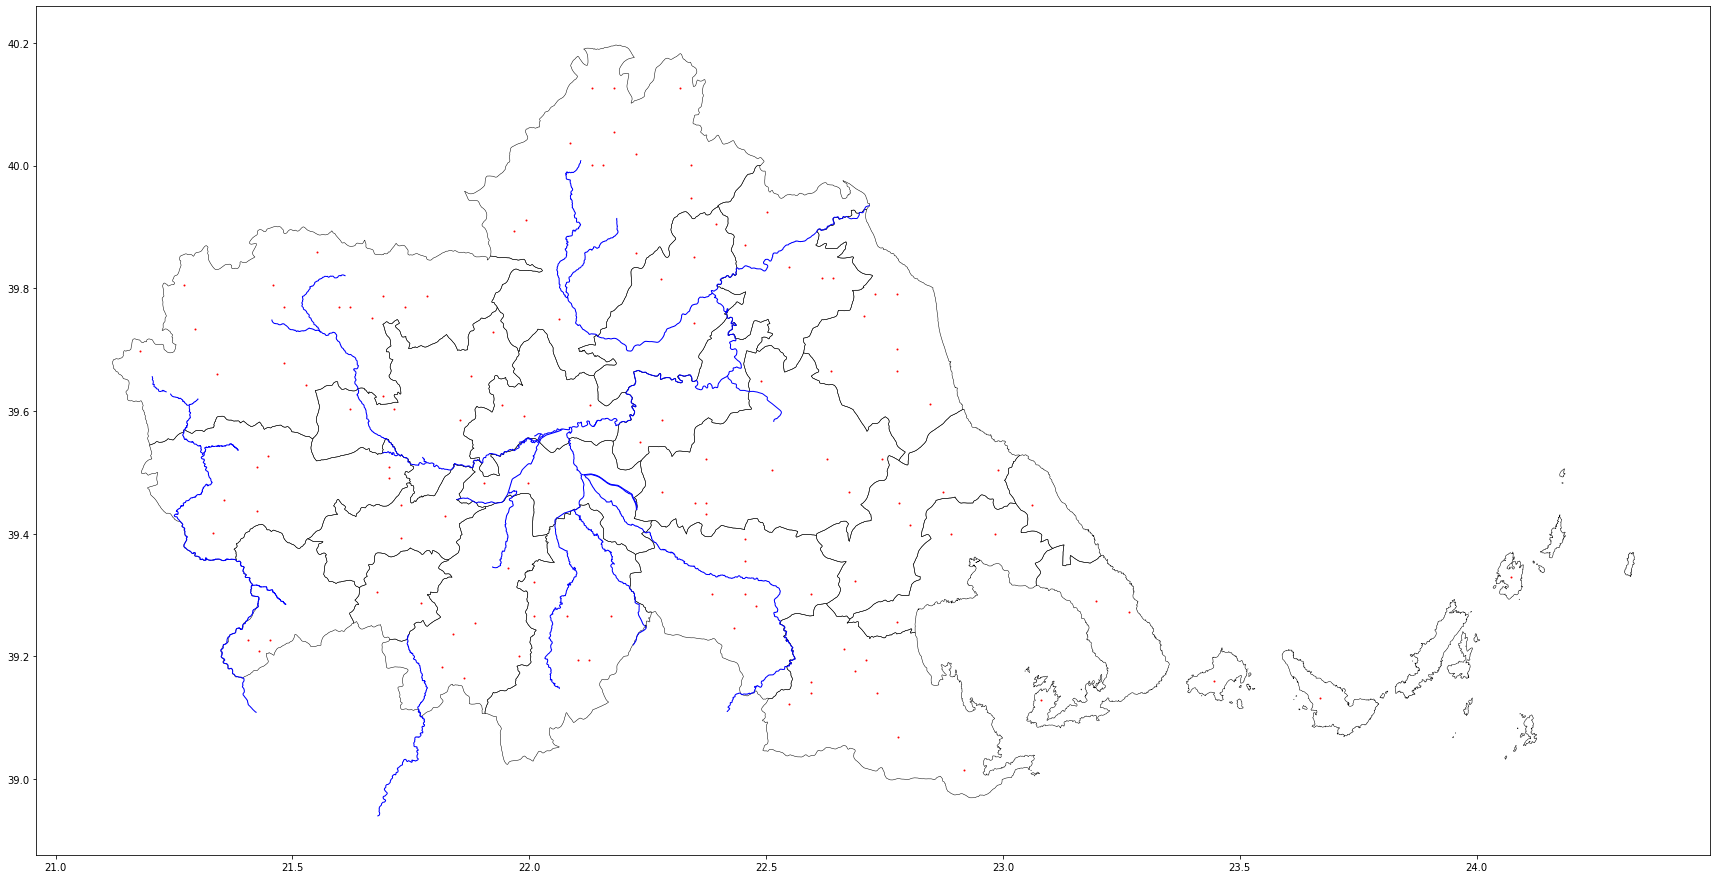

In [44]:
ax = thessaly_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
thessaly_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
thessaly_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [45]:
len(thessaly_grid['lau1'].unique())

25

In [46]:
thessaly_grid

,shape,lau1,x,y,nuts3,geometry
0,"POLYGON ((22.64880 39.65579, 22.64880 39.67375...",αγιας,22.63715,39.66477,θεσσαλιας,POINT (22.63715 39.66477)
1,"POLYGON ((22.71866 39.74562, 22.71866 39.76359...",αγιας,22.70702,39.75460,θεσσαλιας,POINT (22.70702 39.75460)
2,"POLYGON ((22.74195 39.78155, 22.74195 39.79952...",αγιας,22.73031,39.79054,θεσσαλιας,POINT (22.73031 39.79054)
3,"POLYGON ((22.78853 39.65579, 22.78853 39.67375...",αγιας,22.77688,39.66477,θεσσαλιας,POINT (22.77688 39.66477)
4,"POLYGON ((22.78853 39.69172, 22.78853 39.70969...",αγιας,22.77688,39.70070,θεσσαλιας,POINT (22.77688 39.70070)
...,...,...,...,...,...,...
121,"POLYGON ((22.46756 39.29205, 22.46756 39.31001...",φαρσαλων,22.45598,39.30103,θεσσαλιας,POINT (22.45598 39.30103)
122,"POLYGON ((22.46756 39.34595, 22.46756 39.36391...",φαρσαλων,22.45598,39.35493,θεσσαλιας,POINT (22.45598 39.35493)
123,"POLYGON ((22.46756 39.38188, 22.46756 39.39985...",φαρσαλων,22.45598,39.39086,θεσσαλιας,POINT (22.45598 39.39086)
124,"POLYGON ((22.49072 39.27408, 22.49072 39.29205...",φαρσαλων,22.47914,39.28306,θεσσαλιας,POINT (22.47914 39.28306)


In [47]:
start = start_dt = date(2010, 1, 1)
end = end_dt = date(2021, 12, 31)
delta = timedelta(days=1)

In [48]:
dates = []

while start_dt <= end_dt:
    dates.append(start_dt.isoformat())
    start_dt += delta

In [49]:
print('Dates between', start, 'and', end)
print(dates)

Dates between 2010-01-01 and 2021-12-31
['2010-01-01', '2010-01-02', '2010-01-03', '2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07', '2010-01-08', '2010-01-09', '2010-01-10', '2010-01-11', '2010-01-12', '2010-01-13', '2010-01-14', '2010-01-15', '2010-01-16', '2010-01-17', '2010-01-18', '2010-01-19', '2010-01-20', '2010-01-21', '2010-01-22', '2010-01-23', '2010-01-24', '2010-01-25', '2010-01-26', '2010-01-27', '2010-01-28', '2010-01-29', '2010-01-30', '2010-01-31', '2010-02-01', '2010-02-02', '2010-02-03', '2010-02-04', '2010-02-05', '2010-02-06', '2010-02-07', '2010-02-08', '2010-02-09', '2010-02-10', '2010-02-11', '2010-02-12', '2010-02-13', '2010-02-14', '2010-02-15', '2010-02-16', '2010-02-17', '2010-02-18', '2010-02-19', '2010-02-20', '2010-02-21', '2010-02-22', '2010-02-23', '2010-02-24', '2010-02-25', '2010-02-26', '2010-02-27', '2010-02-28', '2010-03-01', '2010-03-02', '2010-03-03', '2010-03-04', '2010-03-05', '2010-03-06', '2010-03-07', '2010-03-08', '2010-03-09', '2010-0

In [50]:
len(dates)

4383

In [51]:
thessaly_timeline = pd.DataFrame()

In [52]:
for index, row in thessaly_grid.iterrows():
    for date in dates:
        thessaly_timeline = thessaly_timeline.append({'lau1' : row['lau1'], 
                                                  'region' : row['nuts3'], 
                                                  'x' : row['x'],
                                                  'y' : row['y'],
                                                  'dt_placement': date}, 
                                                  ignore_index = True)

In [53]:
thessaly_timeline

,lau1,region,x,y,dt_placement
0,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-01
1,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-02
2,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-03
3,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-04
4,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-05
...,...,...,...,...,...
552253,φαρσαλων,θεσσαλιας,22.59495,39.30103,2021-12-27
552254,φαρσαλων,θεσσαλιας,22.59495,39.30103,2021-12-28
552255,φαρσαλων,θεσσαλιας,22.59495,39.30103,2021-12-29
552256,φαρσαλων,θεσσαλιας,22.59495,39.30103,2021-12-30


In [54]:
thessaly_timeline['dt_placement'] = pd.to_datetime(thessaly_timeline['dt_placement'])

In [55]:
thessaly_timeline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552258 entries, 0 to 552257
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   lau1          552258 non-null  object        
 1   region        552258 non-null  object        
 2   x             552258 non-null  float64       
 3   y             552258 non-null  float64       
 4   dt_placement  552258 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 21.1+ MB


In [56]:
thessaly_timeline.to_csv('data/GR_Thessaly_Spatiotemporal_Timeline_2010-2021.csv', index = False)

In [57]:
thessaly_timeline

,lau1,region,x,y,dt_placement
0,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-01
1,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-02
2,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-03
3,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-04
4,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-05
...,...,...,...,...,...
552253,φαρσαλων,θεσσαλιας,22.59495,39.30103,2021-12-27
552254,φαρσαλων,θεσσαλιας,22.59495,39.30103,2021-12-28
552255,φαρσαλων,θεσσαλιας,22.59495,39.30103,2021-12-29
552256,φαρσαλων,θεσσαλιας,22.59495,39.30103,2021-12-30


In [58]:
thessaly_timeline['dt_placement'].iloc[15].day

16

In [59]:
thessaly_timeline_biweekly = thessaly_timeline.copy()
remove = []

for index, row in thessaly_timeline.iterrows():
    if row['dt_placement'].day == 1 or row['dt_placement'].day == 16:
        pass
    else:
        remove.append(index)


thessaly_timeline_biweekly.drop(index = remove, axis = 1, inplace = True)
thessaly_timeline_biweekly.reset_index(inplace = True, drop = True)

In [60]:
thessaly_timeline_biweekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36288 entries, 0 to 36287
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   lau1          36288 non-null  object        
 1   region        36288 non-null  object        
 2   x             36288 non-null  float64       
 3   y             36288 non-null  float64       
 4   dt_placement  36288 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 1.4+ MB


In [61]:
thessaly_timeline_biweekly.to_csv('data/GR_Thessaly_Spatiotemporal_Timeline_Biweekly_2010-2021.csv', index = False)